In [6]:
!git clone https://github.com/Break-Through-Tech/Ursa-Space-Systems-1B-cloud-detection-in-very-high-resolution-optical-satellite-imagery.git

fatal: destination path 'Ursa-Space-Systems-1B-cloud-detection-in-very-high-resolution-optical-satellite-imagery' already exists and is not an empty directory.


# VHR Imagery Foundation: Working with Maxar Open Data

This notebook covers the foundations for working with Very-High-Resolution (VHR) optical satellite imagery from the Maxar Open Data Program. You'll learn to:

1. Set up the environment with geospatial Python libraries
2. Access and explore the Maxar Open Data catalog
3. Load and display VHR imagery from cloud-optimized GeoTIFFs
4. Use window-reading techniques for large imagery files
5. Characterize clouds, smoke, and cloud-like surfaces in VHR scenes
6. Assemble a working set of scenes with higher cloud cover

**Deliverable:** A notebook that loads, displays, and tiles VHR imagery, plus a written characterization of what clouds, smoke, and cloud-like surfaces look like in these scenes.

## 1. Environment Setup

In [2]:
# Install required packages (run this first time)
%pip install rasterio leafmap pystac-client matplotlib numpy scipy requests

# Import libraries
import rasterio
from rasterio.windows import Window
from rasterio.plot import show
import matplotlib.pyplot as plt
import numpy as np
import requests
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Note: you may need to restart the kernel to use updated packages.
Libraries imported successfully!


## 2. Data Loading

In [6]:
import requests
from pathlib import Path

def download_image_from_url(url, save_dir='/workspaces/Ursa-Space-Systems-1B-cloud-detection-in-very-high-resolution-optical-satellite-imagery/data', filename=None):
    """
    Downloads an image from a given URL and saves it to a specified directory.
    """
    # Ensure destination directory exists
    dest_path = Path(save_dir)
    dest_path.mkdir(parents=True, exist_ok=True)

    # Determine filename from URL if not provided
    if not filename:
        filename = url.split('/')[-1]
        if '?' in filename:
            filename = filename.split('?')[0]

    output_file = dest_path / filename

    print(f"Downloading {url} ...")
    try:
        response = requests.get(url, stream=True, timeout=30)
        response.raise_for_status()

        with open(output_file, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
        print(f"✓ Successfully downloaded and saved to: {output_file}")
        return output_file
    except Exception as e:
        print(f"✗ Failed to download image: {e}")
        return None

image_url = "https://maxar-opendata.s3.amazonaws.com/events/Floods-Spain-Oct24/collection.json"
downloaded_file = download_image_from_url(image_url)
image2_url ="https://browser.moregeo.it/external/maxar-opendata.s3.amazonaws.com/events/Floods-Spain-Oct24/ard/acquisition_collections/10300101074E6F00_collection.json"
downloaded_file2 = download_image_from_url(image2_url)

✓ Successfully downloaded and saved to: /workspaces/Ursa-Space-Systems-1B-cloud-detection-in-very-high-resolution-optical-satellite-imagery/data/collection.json
✓ Successfully downloaded and saved to: /workspaces/Ursa-Space-Systems-1B-cloud-detection-in-very-high-resolution-optical-satellite-imagery/data/10300101074E6F00_collection.json


In [9]:
import json
import requests
from pathlib import Path
from urllib.parse import urljoin

def download_multiple_scenes(max_scenes=3):
    collection_path = Path('/workspaces/Ursa-Space-Systems-1B-cloud-detection-in-very-high-resolution-optical-satellite-imagery/data/collection.json')
    if not collection_path.exists():
        print("collection.json not found! Please run the setup cells first.")
        return

    with open(collection_path, 'r') as f:
        metadata = json.load(f)

    links = metadata.get('links', [])
    child_links = [l['href'] for l in links if l.get('rel') == 'child']
    print(f"Found {len(child_links)} child collections available.")

    downloaded_count = 0
    base_url = "https://maxar-opendata.s3.amazonaws.com/events/Floods-Spain-Oct24/"

    # Iterate through child collections
    for idx, child_rel_path in enumerate(child_links):
        if downloaded_count >= max_scenes:
            break

        child_collection_url = urljoin(base_url, child_rel_path.lstrip('./'))
        print(f"\n[{idx+1}/{len(child_links)}] Fetching child collection: {child_collection_url}")

        try:
            child_response = requests.get(child_collection_url, timeout=15)
            if child_response.status_code != 200:
                continue

            child_data = child_response.json()
            item_urls = [l['href'] for l in child_data.get('links', []) if l.get('rel') == 'item']

            if not item_urls:
                continue

            # Grab the first item in the collection
            item_url = urljoin(child_collection_url, item_urls[0])
            item_response = requests.get(item_url, timeout=15)
            if item_response.status_code != 200:
                continue

            item_data = item_response.json()
            assets = item_data.get('assets', {})

            # Look for a .tif image
            tif_url = None
            for asset_val in assets.values():
                href = asset_val.get('href', '')
                if href.endswith('.tif') or href.endswith('.tiff'):
                    tif_url = href
                    break

            if tif_url:
                absolute_tif_url = urljoin(item_url, tif_url)
                filename = f"scene_{downloaded_count + 1}_{absolute_tif_url.split('/')[-1]}"

                # Download the image
                download_image_from_url(absolute_tif_url, filename=filename)
                downloaded_count += 1
        except Exception as e:
            print(f"Error processing child collection {idx}: {e}")

    print(f"\nFinished! Successfully downloaded {downloaded_count} scenes.")

# Let's download 3 different scenes
download_multiple_scenes(max_scenes=3)

Found 12 child collections available.

[1/12] Fetching child collection: https://maxar-opendata.s3.amazonaws.com/events/Floods-Spain-Oct24/ard/acquisition_collections/10300101074E6F00_collection.json


✓ Successfully downloaded and saved to: /workspaces/Ursa-Space-Systems-1B-cloud-detection-in-very-high-resolution-optical-satellite-imagery/data/scene_1_10300101074E6F00-ms.tif

[2/12] Fetching child collection: https://maxar-opendata.s3.amazonaws.com/events/Floods-Spain-Oct24/ard/acquisition_collections/1030010107742A00_collection.json
✓ Successfully downloaded and saved to: /workspaces/Ursa-Space-Systems-1B-cloud-detection-in-very-high-resolution-optical-satellite-imagery/data/scene_2_1030010107742A00-ms.tif

[3/12] Fetching child collection: https://maxar-opendata.s3.amazonaws.com/events/Floods-Spain-Oct24/ard/acquisition_collections/1030010108767300_collection.json
✓ Successfully downloaded and saved to: /workspaces/Ursa-Space-Systems-1B-cloud-detection-in-very-high-resolution-optical-satellite-imagery/data/scene_3_1030010108767300-ms.tif

Finished! Successfully downloaded 3 scenes.


In [12]:
# Check for local image files in the data directory
data_dir = Path('/workspaces/Ursa-Space-Systems-1B-cloud-detection-in-very-high-resolution-optical-satellite-imagery/data')
image_files = list(data_dir.glob('*.tif')) + list(data_dir.glob('*.json')) + list(data_dir.glob('*.tiff')) + list(data_dir.glob('*.png')) + list(data_dir.glob('*.jpg'))

if image_files:
    print(f"Found {len(image_files)} image files in data directory:")
    for img_file in image_files:
        print(f"  - {img_file.name}")
else:
    print("No image files found in data directory.")
    print("Please download some VHR imagery and save it to the data/ directory.")
    print("\nFor testing purposes, you can also use the sample approach below.")

Found 5 image files in data directory:
  - scene_2_1030010107742A00-ms.tif
  - scene_3_1030010108767300-ms.tif
  - scene_1_10300101074E6F00-ms.tif
  - 10300101074E6F00_collection.json
  - collection.json


## 4. Working with Local Image Files

Once you have image files (either downloaded or local), use these functions to work with them.

In [13]:
def load_local_image(image_path):
    """
    Load a local image file using rasterio

    Parameters:
    -----------
    image_path : str or Path
        Path to the image file

    Returns:
    --------
    rasterio dataset object
    """
    try:
        src = rasterio.open(image_path)
        print(f"Successfully loaded: {image_path}")
        print(f"Dimensions: {src.width} x {src.height}")
        print(f"Bands: {src.count}")
        print(f"CRS: {src.crs}")
        return src
    except Exception as e:
        print(f"Error loading image: {e}")
        return None

# Example usage (uncomment when you have local files):
if image_files:
  src = load_local_image(image_files[0])
  if src:
    pass

Successfully loaded: /workspaces/Ursa-Space-Systems-1B-cloud-detection-in-very-high-resolution-optical-satellite-imagery/data/scene_2_1030010107742A00-ms.tif
Dimensions: 2819 x 2819
Bands: 8
CRS: EPSG:32630


## 5. Window-Reading Techniques

Since VHR images are very large, we'll use window-reading to load specific regions. This is memory-efficient and allows us to explore different parts of the image.

In [14]:
def read_image_window(src, window_size=1024, offset_x=0, offset_y=0):
    """
    Read a window from an image (works with both local files and URLs)

    Parameters:
    -----------
    src : rasterio dataset or URL string
        Either an open rasterio dataset or URL to image
    window_size : int
        Size of the window to read (square)
    offset_x, offset_y : int
        Offset from the top-left corner

    Returns:
    --------
    numpy array, profile dict
    """
    # Handle both rasterio datasets and URLs
    if isinstance(src, str):
        # It's a URL, open it
        dataset = rasterio.open(src)
        should_close = True
    else:
        # It's already a dataset
        dataset = src
        should_close = False

    try:
        # Create a window
        window = Window(offset_x, offset_y, window_size, window_size)

        # Read the data for this window
        window_data = dataset.read(window=window)

        # Get the profile for this window
        window_profile = dataset.profile
        window_profile.update({
            'height': window_size,
            'width': window_size,
            'transform': dataset.window_transform(window)
        })

        return window_data, window_profile
    finally:
        if should_close:
            dataset.close()

print("Window reading function defined successfully!")

Window reading function defined successfully!


## 6. Display and Analysis Functions

These functions will help you display and analyze VHR imagery.

In [15]:
def display_rgb_image(data, title="RGB Image"):
    """
    Display RGB image from rasterio data

    Parameters:
    -----------
    data : numpy array
        Image data with shape (bands, height, width)
    title : str
        Title for the plot
    """
    # Handle different band orders
    if data.shape[0] >= 3:
        # Assume RGB or similar - take first 3 bands
        rgb = data[:3, :, :]
    else:
        rgb = data

    # Transpose from (bands, height, width) to (height, width, bands)
    rgb = np.transpose(rgb, (1, 2, 0))

    # Normalize for display
    rgb = rgb.astype(float)
    rgb_max = rgb.max()
    if rgb_max > 0:
        rgb = np.clip(rgb / rgb_max, 0, 1)

    plt.figure(figsize=(12, 12))
    plt.imshow(rgb)
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def analyze_image_statistics(data):
    """
    Analyze basic statistics of image data useful for cloud detection

    Parameters:
    -----------
    data : numpy array
        Image data with shape (bands, height, width)

    Returns:
    --------
    dict with statistics
    """
    stats = {}

    # Per-band statistics
    for band_idx in range(data.shape[0]):
        band_data = data[band_idx, :, :]
        stats[f'band_{band_idx}'] = {
            'mean': float(np.mean(band_data)),
            'std': float(np.std(band_data)),
            'min': float(np.min(band_data)),
            'max': float(np.max(band_data)),
            'median': float(np.median(band_data))
        }

    # Overall brightness (assuming RGB or similar)
    if data.shape[0] >= 3:
        rgb = data[:3, :, :]
        brightness = np.mean(rgb, axis=0)  # Average across RGB bands
        stats['brightness'] = {
            'mean': float(np.mean(brightness)),
            'std': float(np.std(brightness)),
            'max': float(np.max(brightness))
        }

    return stats

print("Display and analysis functions defined successfully!")

Display and analysis functions defined successfully!


## 7. Simple Cloud Detection

A basic cloud detection algorithm using brightness thresholding.

In [16]:
def simple_cloud_detection(data, brightness_threshold=200):
    """
    Simple cloud detection using brightness threshold

    Parameters:
    -----------
    data : numpy array
        Image data with shape (bands, height, width)
    brightness_threshold : int
        Threshold for considering a pixel as cloud

    Returns:
    --------
    binary mask (numpy array)
    """
    if data.shape[0] >= 3:
        rgb = data[:3, :, :]
        brightness = np.mean(rgb, axis=0)
    else:
        brightness = data[0, :, :]

    cloud_mask = brightness > brightness_threshold
    return cloud_mask.astype(np.uint8)

def display_cloud_detection(data, cloud_mask, title="Cloud Detection"):
    """
    Display original image and cloud mask side by side
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Original
    if data.shape[0] >= 3:
        rgb = data[:3, :, :]
    else:
        rgb = data
    rgb = np.transpose(rgb, (1, 2, 0))
    rgb = rgb.astype(float)
    rgb_max = rgb.max()
    if rgb_max > 0:
        rgb = np.clip(rgb / rgb_max, 0, 1)
    ax1.imshow(rgb)
    ax1.set_title('Original Image')
    ax1.axis('off')

    # Cloud mask
    ax2.imshow(cloud_mask, cmap='gray')
    ax2.set_title('Cloud Detection (Brightness Threshold)')
    ax2.axis('off')

    plt.tight_layout()
    plt.show()

    cloud_coverage = np.mean(cloud_mask) * 100
    print(f"Cloud coverage: {cloud_coverage:.2f}%")

print("Cloud detection functions defined successfully!")

Cloud detection functions defined successfully!


## 8. Tile Generation Function

Generate multiple tiles across an image for comprehensive analysis.

In [17]:
def generate_tiles(src, grid_size=3, window_size=512):
    """
    Generate multiple tiles across the image

    Parameters:
    -----------
    src : rasterio dataset or URL string
        Either an open rasterio dataset or URL to image
    grid_size : int
        Number of tiles per row/column (grid_size x grid_size total)
    window_size : int
        Size of each tile

    Returns:
    --------
    list of (data, coordinates) tuples
    """
    tiles = []

    # Handle both rasterio datasets and URLs
    if isinstance(src, str):
        dataset = rasterio.open(src)
        should_close = True
    else:
        dataset = src
        should_close = False

    try:
        img_width, img_height = dataset.width, dataset.height

        # Calculate spacing between tiles
        x_spacing = img_width // grid_size
        y_spacing = img_height // grid_size

        for i in range(grid_size):
            for j in range(grid_size):
                # Calculate tile position
                offset_x = i * x_spacing
                offset_y = j * y_spacing

                # Adjust window size if near edges
                actual_window_size = min(window_size,
                                         img_width - offset_x,
                                         img_height - offset_y)

                if actual_window_size > 0:
                    window = Window(offset_x, offset_y, actual_window_size, actual_window_size)
                    tile_data = dataset.read(window=window)
                    tiles.append((tile_data, (offset_x, offset_y)))
    finally:
        if should_close:
            dataset.close()

    return tiles

def display_tile_grid(tiles, grid_size=3):
    """
    Display tiles in a grid layout
    """
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(15, 15))
    axes = axes.flatten()

    for idx, (tile_data, coords) in enumerate(tiles):
        if idx >= len(axes):
            break

        # Process RGB
        if tile_data.shape[0] >= 3:
            rgb = tile_data[:3, :, :]
        else:
            rgb = tile_data

        rgb = np.transpose(rgb, (1, 2, 0))
        rgb = rgb.astype(float)
        rgb_max = rgb.max()
        if rgb_max > 0:
            rgb = np.clip(rgb / rgb_max, 0, 1)

        axes[idx].imshow(rgb)
        axes[idx].set_title(f"Tile {idx+1} (offset: {coords})")
        axes[idx].axis('off')

    # Hide unused subplots
    for idx in range(len(tiles), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

print("Tile generation functions defined successfully!")

Tile generation functions defined successfully!


## 9. Example Workflow

Successfully loaded: /workspaces/Ursa-Space-Systems-1B-cloud-detection-in-very-high-resolution-optical-satellite-imagery/data/scene_3_1030010108767300-ms.tif
Dimensions: 2518 x 2518
Bands: 8
CRS: EPSG:32630
Window data shape: (8, 1024, 1024)


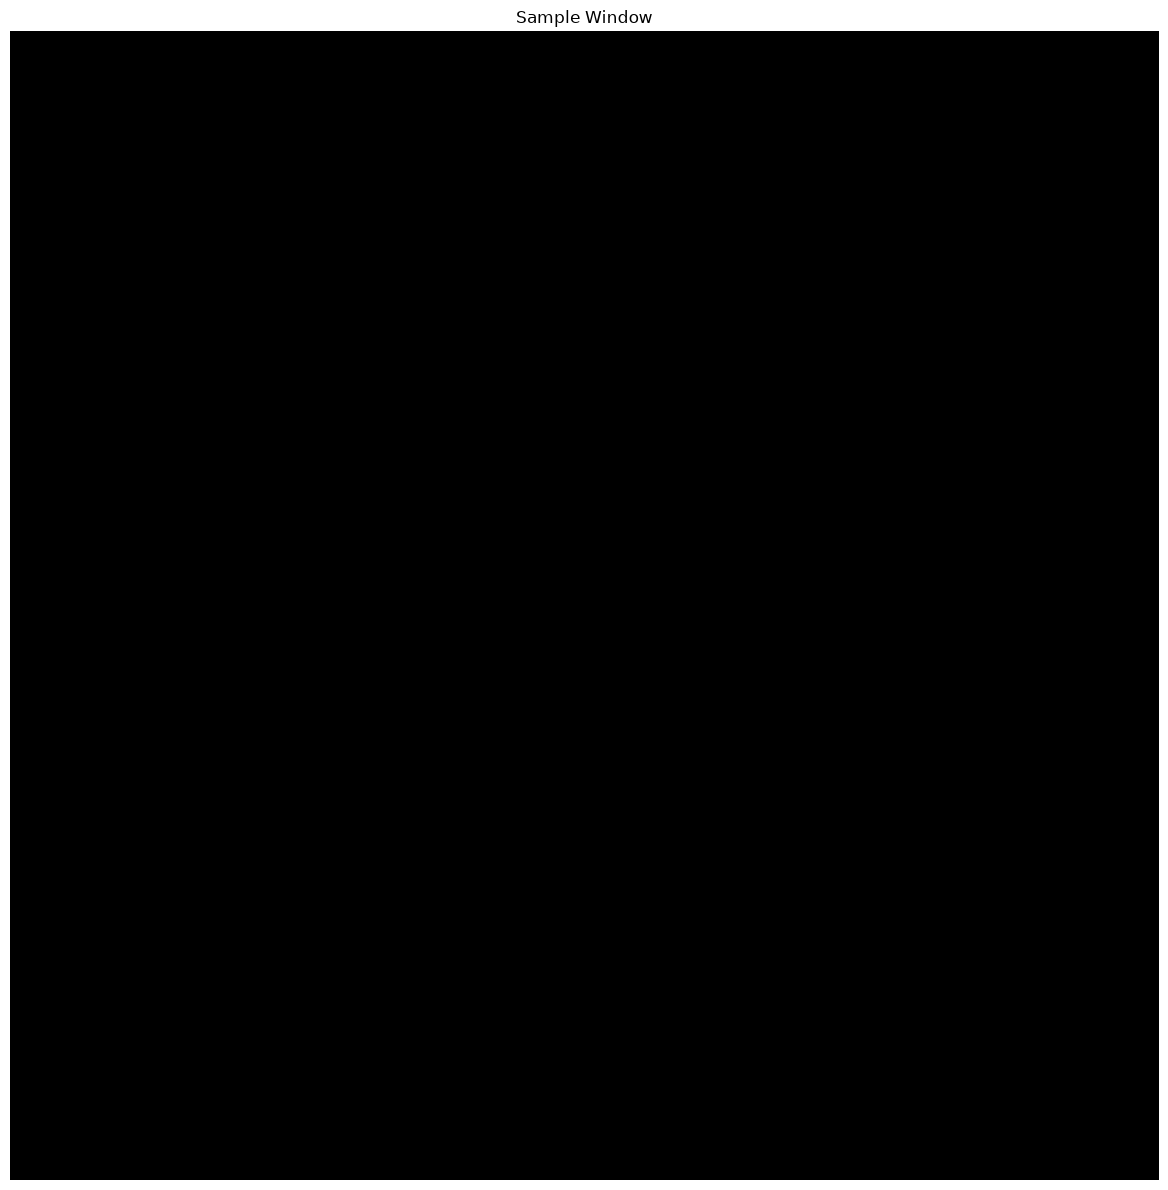

Brightness statistics: {'mean': 0.0, 'std': 0.0, 'max': 0.0}


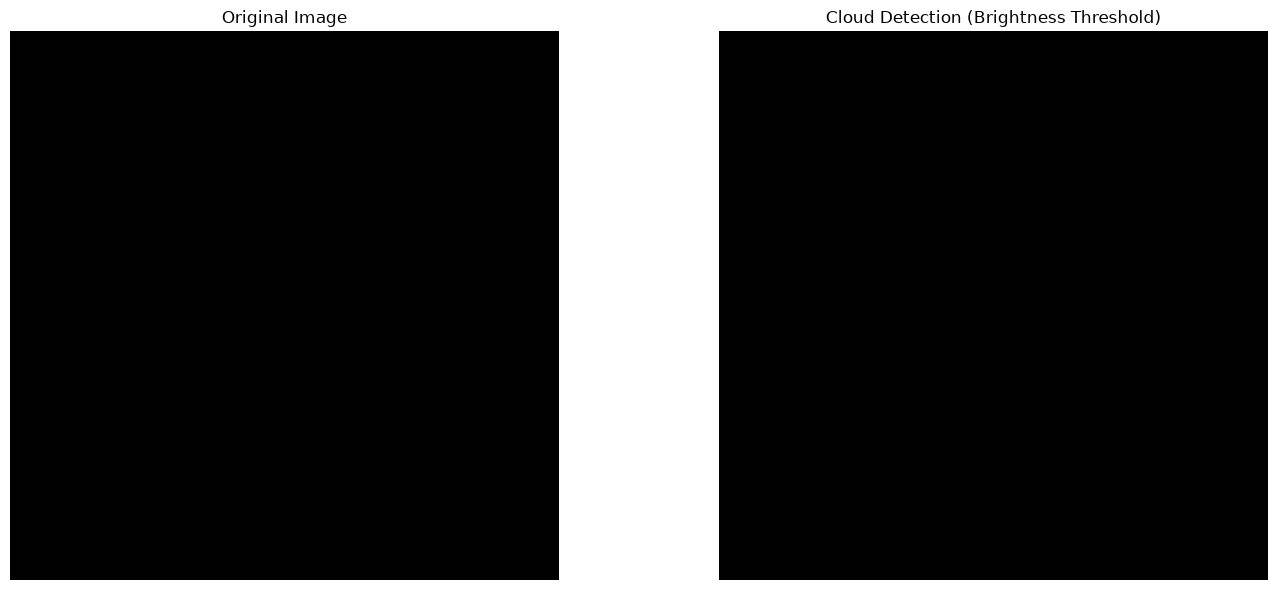

Cloud coverage: 0.00%
Generated 9 tiles


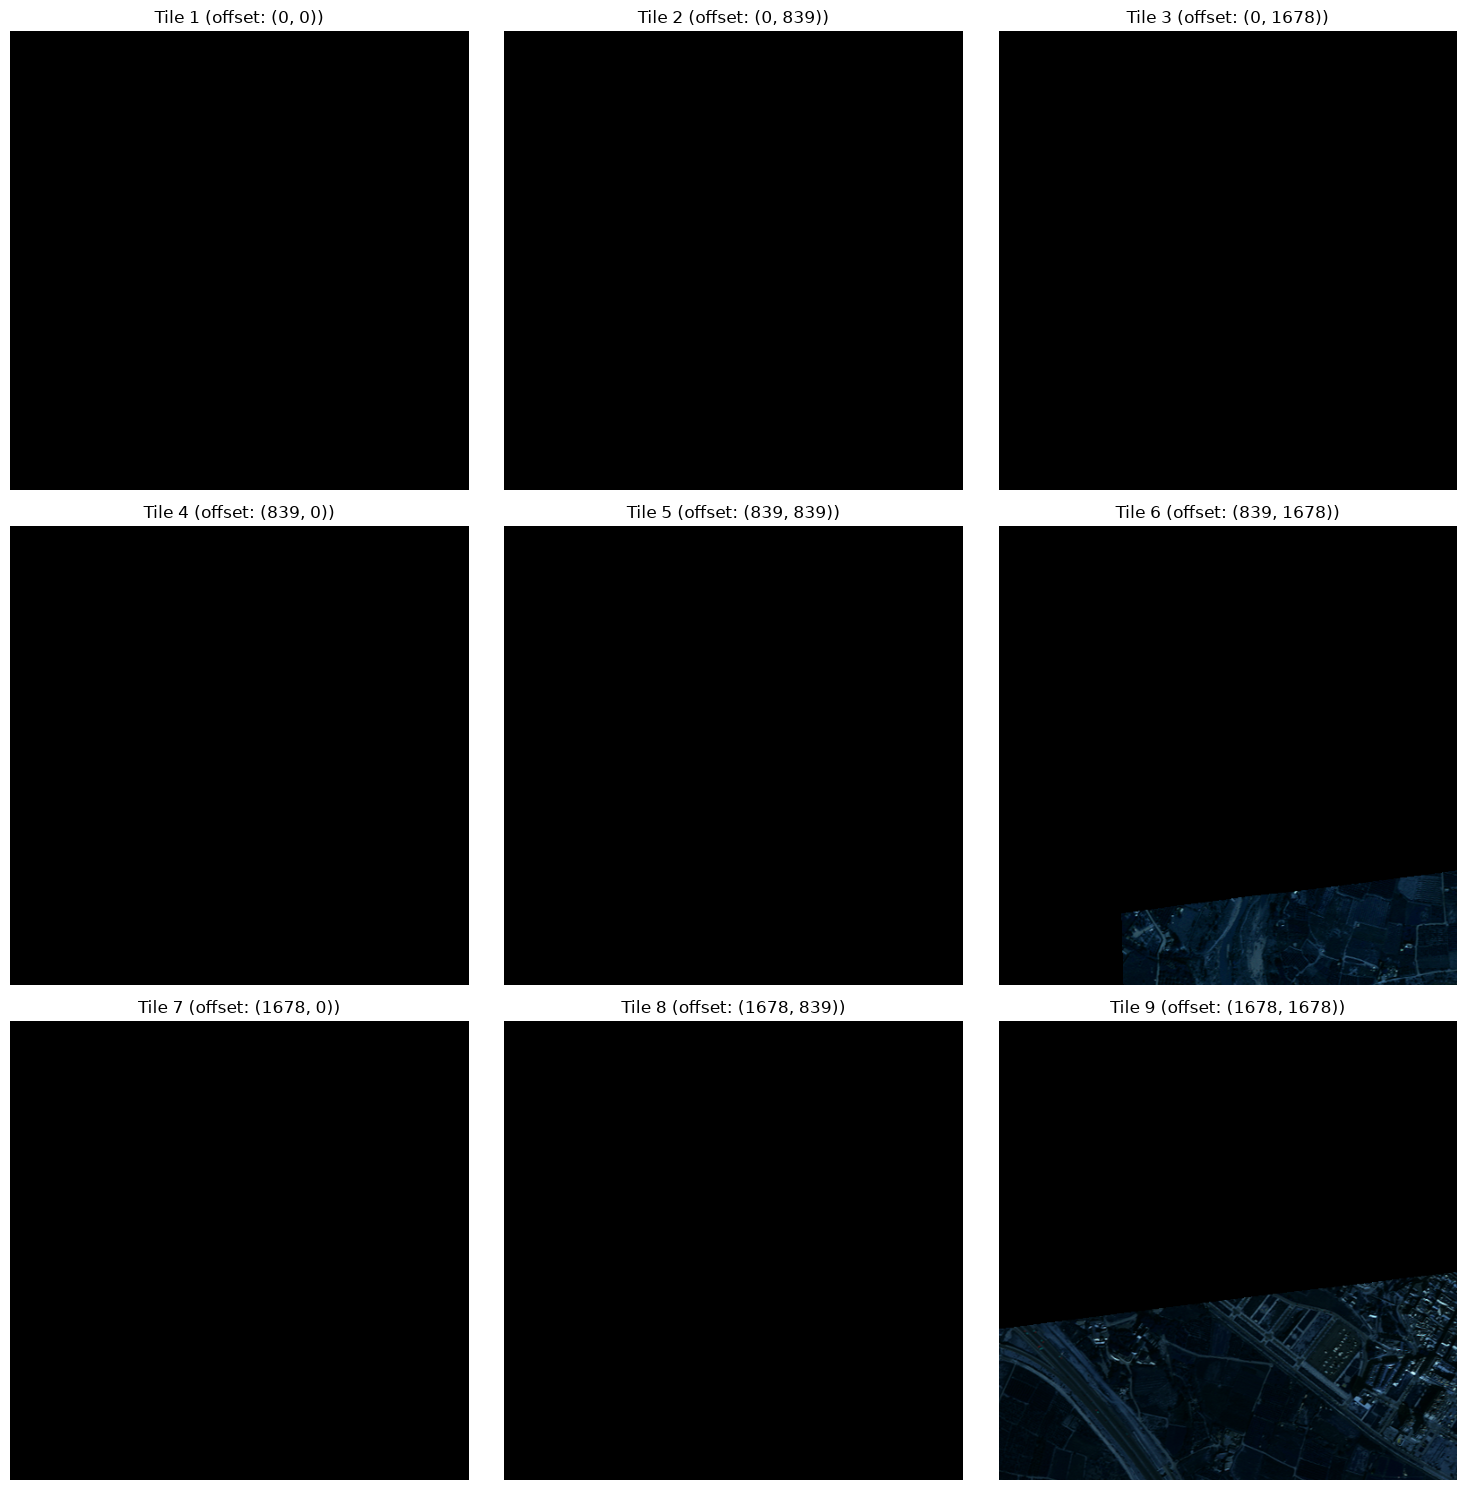

Tile 1 (offset: (0, 0)): Brightness mean=0.00
Tile 2 (offset: (0, 839)): Brightness mean=0.00
Tile 3 (offset: (0, 1678)): Brightness mean=0.00
Tile 4 (offset: (839, 0)): Brightness mean=0.00
Tile 5 (offset: (839, 839)): Brightness mean=0.00
Tile 6 (offset: (839, 1678)): Brightness mean=88.77
Tile 7 (offset: (1678, 0)): Brightness mean=0.00
Tile 8 (offset: (1678, 839)): Brightness mean=0.00
Tile 9 (offset: (1678, 1678)): Brightness mean=332.28


In [25]:
# Step 1: Load an image
image_path = "/workspaces/Ursa-Space-Systems-1B-cloud-detection-in-very-high-resolution-optical-satellite-imagery/data/scene_3_1030010108767300-ms.tif"
src = load_local_image(image_path)

if src:
    # Step 2: Read a window from the center
    window_size = min(1024, src.width, src.height)
    offset_x = (src.width - window_size) // 2
    offset_y = (src.height - window_size) // 2

    window_data, window_profile = read_image_window(src, window_size, offset_x, offset_y)
    print(f"Window data shape: {window_data.shape}")

    # Step 3: Display the window
    display_rgb_image(window_data, "Sample Window")

    # Step 4: Analyze statistics
    stats = analyze_image_statistics(window_data)
    print(f"Brightness statistics: {stats['brightness']}")

    # Step 5: Apply cloud detection
    cloud_mask = simple_cloud_detection(window_data, brightness_threshold=200)
    display_cloud_detection(window_data, cloud_mask)

    # Step 6: Generate tiles
    tiles = generate_tiles(src, grid_size=3, window_size=512)
    print(f"Generated {len(tiles)} tiles")
    display_tile_grid(tiles, grid_size=3)

    # Step 7: Analyze each tile
    for idx, (tile_data, coords) in enumerate(tiles):
        stats = analyze_image_statistics(tile_data)
        print(f"Tile {idx+1} (offset: {coords}): Brightness mean={stats['brightness']['mean']:.2f}")

    src.close()


### Batch Processing Multiple Images
You can automate the workflow to process all available images in your data directory sequentially. This allows you to collect statistics across multiple scenes automatically.

In [26]:
import pandas as pd

def process_all_images(directory_path, brightness_threshold=200):
    """
    Batch processes all .tif images in the specified directory.
    """
    data_dir = Path(directory_path)
    tiff_files = list(data_dir.glob('*.tif')) + list(data_dir.glob('*.tiff'))

    if not tiff_files:
        print("No TIFF images found to process.")
        return

    print(f"Found {len(tiff_files)} images. Starting batch processing...\n")
    results = []

    for img_path in tiff_files:
        print(f"Processing: {img_path.name}")
        src = load_local_image(img_path)

        if src:
            # Read a central window
            window_size = min(1024, src.width, src.height)
            offset_x = (src.width - window_size) // 2
            offset_y = (src.height - window_size) // 2

            window_data, _ = read_image_window(src, window_size, offset_x, offset_y)

            # Analyze statistics
            stats = analyze_image_statistics(window_data)

            # Detect clouds and compute coverage percentage
            cloud_mask = simple_cloud_detection(window_data, brightness_threshold=brightness_threshold)
            cloud_coverage = np.mean(cloud_mask) * 100

            # Store summary metrics
            results.append({
                "Image Name": img_path.name,
                "Width": src.width,
                "Height": src.height,
                "Bands": src.count,
                "Avg Brightness": stats['brightness']['mean'],
                "Cloud Coverage (%)": round(cloud_coverage, 2)
            })

            src.close()
            print(f"✓ Finished {img_path.name} | Cloud Coverage: {cloud_coverage:.2f}%\n")

    # Display summary as a Pandas DataFrame
    summary_df = pd.DataFrame(results)
    display(summary_df)
    return summary_df

# Run the batch process on your data folder
summary_results = process_all_images('/workspaces/Ursa-Space-Systems-1B-cloud-detection-in-very-high-resolution-optical-satellite-imagery/data')

Found 3 images. Starting batch processing...

Processing: scene_2_1030010107742A00-ms.tif
Successfully loaded: /workspaces/Ursa-Space-Systems-1B-cloud-detection-in-very-high-resolution-optical-satellite-imagery/data/scene_2_1030010107742A00-ms.tif
Dimensions: 2819 x 2819
Bands: 8
CRS: EPSG:32630
✓ Finished scene_2_1030010107742A00-ms.tif | Cloud Coverage: 76.29%

Processing: scene_3_1030010108767300-ms.tif
Successfully loaded: /workspaces/Ursa-Space-Systems-1B-cloud-detection-in-very-high-resolution-optical-satellite-imagery/data/scene_3_1030010108767300-ms.tif
Dimensions: 2518 x 2518
Bands: 8
CRS: EPSG:32630
✓ Finished scene_3_1030010108767300-ms.tif | Cloud Coverage: 0.00%

Processing: scene_1_10300101074E6F00-ms.tif
Successfully loaded: /workspaces/Ursa-Space-Systems-1B-cloud-detection-in-very-high-resolution-optical-satellite-imagery/data/scene_1_10300101074E6F00-ms.tif
Dimensions: 2040 x 2040
Bands: 8
CRS: EPSG:32630
✓ Finished scene_1_10300101074E6F00-ms.tif | Cloud Coverage: 61.

,Image Name,Width,Height,Bands,Avg Brightness,Cloud Coverage (%)
0,scene_2_1030010107742A00-ms.tif,2819,2819,8,1203.809336,76.29
1,scene_3_1030010108767300-ms.tif,2518,2518,8,0.000000,0.00
2,scene_1_10300101074E6F00-ms.tif,2040,2040,8,1125.013203,61.21


## Characterization Summary

Based on cloud detection literature, here are the expected characteristics of different cloud types and cloud-like surfaces in VHR imagery:

In [27]:
characterization = {
    "thick_clouds": {
        "visual_characteristics": "Bright white, high reflectance, opaque texture",
        "brightness_range": "Very high (typically >200 on 0-255 scale)",
        "spectral_properties": "High reflectance across all RGB bands",
        "detection_challenges": "Generally easy to detect with simple brightness thresholds"
    },
    "thin_clouds": {
        "visual_characteristics": "Semi-transparent, allow ground features to be visible",
        "brightness_range": "Moderate to high (150-200 range)",
        "spectral_properties": "Moderate reflectance, may have haze-like appearance",
        "detection_challenges": "Harder to detect, may be confused with bright surfaces"
    },
    "smoke": {
        "visual_characteristics": "Grayish/brownish, often from wildfires or industrial sources",
        "brightness_range": "Variable, often lower than thick clouds",
        "spectral_properties": "Different spectral signature than water clouds",
        "detection_challenges": "Can be confused with clouds, requires spectral analysis"
    },
    "snow": {
        "visual_characteristics": "Bright white, similar to thick clouds",
        "brightness_range": "Very high, similar to thick clouds",
        "spectral_properties": "High reflectance, but different spatial patterns",
        "detection_challenges": "Very difficult to distinguish from clouds using RGB alone"
    },
    "bright_rooftops": {
        "visual_characteristics": "Geometric shapes, urban context, high reflectance",
        "brightness_range": "High, but localized to structures",
        "spectral_properties": "High reflectance, but with sharp edges and regular patterns",
        "detection_challenges": "Can be misclassified as clouds without context"
    },
    "sand_deserts": {
        "visual_characteristics": "Light colored, extensive areas, natural textures",
        "brightness_range": "High, but often lower than thick clouds",
        "spectral_properties": "Consistent coloration, natural variations",
        "detection_challenges": "May be confused with thin clouds or haze"
    }
}

print("Expected Characteristics of Cloud Types and Cloud-like Surfaces:")
print(json.dumps(characterization, indent=2))

Expected Characteristics of Cloud Types and Cloud-like Surfaces:
{
  "thick_clouds": {
    "visual_characteristics": "Bright white, high reflectance, opaque texture",
    "brightness_range": "Very high (typically >200 on 0-255 scale)",
    "spectral_properties": "High reflectance across all RGB bands",
    "detection_challenges": "Generally easy to detect with simple brightness thresholds"
  },
  "thin_clouds": {
    "visual_characteristics": "Semi-transparent, allow ground features to be visible",
    "brightness_range": "Moderate to high (150-200 range)",
    "spectral_properties": "Moderate reflectance, may have haze-like appearance",
    "detection_challenges": "Harder to detect, may be confused with bright surfaces"
  },
  "smoke": {
    "visual_characteristics": "Grayish/brownish, often from wildfires or industrial sources",
    "brightness_range": "Variable, often lower than thick clouds",
    "spectral_properties": "Different spectral signature than water clouds",
    "detectio

## 12. Next Steps
- Run the batch processing over multiple retrieved events.
- Enhance the cloud mask logic with multi-spectral band thresholds.